# Session 4 &mdash; Filters & Convolution (lab)
**George Hanna** · Computer Vision & Speech Recognition (EADA) · dataset: MILK10k

This notebook is Part 2 of Session 4: convolution implemented from scratch, checked against every example worked
by hand in the slides, and then applied to a real MILK10k lesion.

| § | What | Slides |
|---|---|---|
| 0 | The 5×5 toy image and the eight kernels | 11, 34 |
| 1 | One window computed by hand, in code | 8, 10, 12 |
| 2 | Output size, padding and stride | 16–18, 44 |
| 3 | `conv2d` from scratch, checked against all hand-worked outputs | 9, 12–34 |
| 4 | Blur, sharpen, emboss, outline and Sobel on lesion ISIC_0073863: my `conv2d` vs. `fast_conv2d` (SciPy) | 20–32 |
| 5 | Speed: naive loops vs. vectorized NumPy vs. SciPy | 48 |
| 6 | Convolution vs. correlation | 36 |
| 7 | From one hand-made kernel to a CNN layer (`torch.nn.Conv2d`) | 35, 37 |

**How to run.** The data folder is set in one place, `milk10k/config.py` (environment variable `MILK10K_DIR`, or a
`data/` link at the repository root; see README). Run with *Restart & Run All* (about 30 seconds).

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
import torch
from torch import nn

from milk10k import config
from milk10k.data import load_metadata, image_path
from milk10k.preprocessing import preprocess_image
from milk10k.visualize import apply_style

apply_style()
np.set_printoptions(precision=1, suppress=True, linewidth=120)
FIG_DIR = config.FIGURES_DIR / "session4"      # figures of this notebook are also saved here


def show_and_save(fig, name):
    # Save the figure to figures/session4/ and show it in the notebook.
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / name)
    plt.show()


def fmt(v):
    # 60.0 -> "60", 44.44 -> "44.4" (one decimal, like the slides)
    s = f"{round(float(v), 1) + 0.0:.1f}"
    return s[:-2] if s.endswith(".0") else s


def draw_values(ax, arr, title=""):
    # Draw a small matrix with its numbers written in the cells, like the slides.
    # Grey scale when there are no negative values; otherwise blue = negative, red = positive.
    arr = np.asarray(arr, dtype=float)
    if arr.min() >= 0:
        cmap, lo, hi = "gray", 0.0, max(arr.max(), 1.0)
    else:
        cmap, hi = "coolwarm", np.abs(arr).max()
        lo = -hi
    ax.imshow(arr, cmap=cmap, vmin=lo, vmax=hi)
    for (r, c), v in np.ndenumerate(arr):
        shade = (v - lo) / (hi - lo)                       # 0 = lowest colour, 1 = highest colour
        dark = shade < 0.5 if cmap == "gray" else abs(shade - 0.5) > 0.3
        ax.text(c, r, fmt(v), ha="center", va="center", fontsize=7.5, color="white" if dark else "black")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

## 0. The toy image and the eight kernels (slides 11 and 34)

The 5×5 toy image from the slides: **100 = bright skin, 10 = dark lesion**, the corner of a lesion border. It has a
vertical edge between columns 1 and 2 and a horizontal edge between rows 1 and 2. The eight kernels are the ones
on slide 34.

identity  weights sum to 1
box_blur  weights sum to 1
gaussian  weights sum to 1
sharpen   weights sum to 1
outline   weights sum to 0
emboss    weights sum to 1
sobel_x   weights sum to 0
sobel_y   weights sum to 0


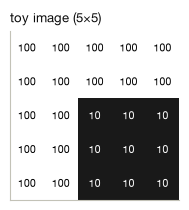

In [2]:
image = np.array([[100, 100, 100, 100, 100],
                [100, 100, 100, 100, 100],
                [100, 100,  10,  10,  10],
                [100, 100,  10,  10,  10],
                [100, 100,  10,  10,  10]], dtype=float)

KERNELS = {
    "identity": np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=float),
    "box_blur": np.ones((3, 3)) / 9,
    "gaussian": np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16,
    "sharpen":  np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=float),
    "outline":  np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=float),
    "emboss":   np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=float),
    "sobel_x":  np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float),
    "sobel_y":  np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=float),
}

for name, kernel in KERNELS.items():
    print(f"{name:9s} weights sum to {kernel.sum():g}")

fig, ax = plt.subplots(figsize=(2.2, 2.2))
draw_values(ax, image, "toy image (5×5)")
plt.show()

**Observation.** The kernels fall into two families. When the weights **sum to 1** (identity, both blurs, sharpen,
emboss), a flat region keeps its brightness. When they **sum to 0** (outline, Sobel), every flat region becomes 0,
so only changes, i.e. edges, survive.

## 1. One window, by hand, in code (slides 8, 10 and 12)

At one position, convolution is: **multiply** each kernel weight by the pixel under it, then **sum** the products.
In NumPy, `window * kernel` multiplies element by element (9 products) and `.sum()` adds them up.

The first patch is the 3×3 window of real pixel values from the slides' 8×8 MILK10k crop (slide 8).

In [3]:
# Slide 10: real pixels from the 8x8 crop, with a box blur
patch = np.array([[118, 22, 94],
                  [110,  6, 13],
                  [142, 41,  0]], dtype=float)
products = patch * KERNELS["box_blur"]        # 9 products, one per kernel cell
print("products × 9 (the pixels themselves, since every weight is 1/9):")
print(products * 9)
print(f"sum = {(products * 9).sum():.0f} / 9 = {products.sum():.1f}   ->  centre pixel {patch[1, 1]:.0f} becomes {products.sum():.1f}")

products × 9 (the pixels themselves, since every weight is 1/9):
[[118.  22.  94.]
 [110.   6.  13.]
 [142.  41.   0.]]
sum = 546 / 9 = 60.7   ->  centre pixel 6 becomes 60.7


The same on the toy image, with the box blur, as coded in class. A window is named by its **top-left corner**
`(row, col)`: the window at (1, 1) covers rows 1–3 and columns 1–3 (slide 14, step 5).

In [4]:
kernel = np.ones((3, 3)) / 9            # box blur
patch = image[1:4, 1:4]                 # window at (1, 1): rows 1-3, columns 1-3
products = patch * kernel               # 9 products, one per kernel cell
print(products)
print(products.sum())

[[11.1 11.1 11.1]
 [11.1  1.1  1.1]
 [11.1  1.1  1.1]]
60.0


In [5]:
def conv_step(image, kernel, row, col):
    """one window: patch -> products -> sum"""
    k = kernel.shape[0]
    patch = image[row:row + k, col:col + k]
    products = patch * kernel
    return patch, products, products.sum()


# position of the window (0, 0)
conv_step(image, kernel, 0, 0)

(array([[100., 100., 100.],
        [100., 100., 100.],
        [100., 100.,  10.]]),
 array([[11.1, 11.1, 11.1],
        [11.1, 11.1, 11.1],
        [11.1, 11.1,  1.1]]),
 np.float64(90.0))

**Observation.** Same numbers as the slides. The real patch gives 546 / 9 = **60.7**: the almost-black centre pixel
(6) is pulled up by its brighter neighbours, which is what blur means. On the toy image, window (1, 1) gives
**60** (4 of its 9 pixels are dark) and window (0, 0) gives **90** (only one dark pixel). `conv_step` returns the
three stages of the computation, `patch → products → sum`, so each one can be checked.

### 1.1 Sliding the kernel (slides 12–15)

A 5×5 input and a 3×3 kernel: the window fits in 5 − 3 + 1 = 3 positions per direction, so the output is 3×3.
`conv_step` is applied at every position, left to right and top to bottom (stride 1, no padding).

[[90. 80. 70.]
 [80. 60. 40.]
 [70. 40. 10.]]


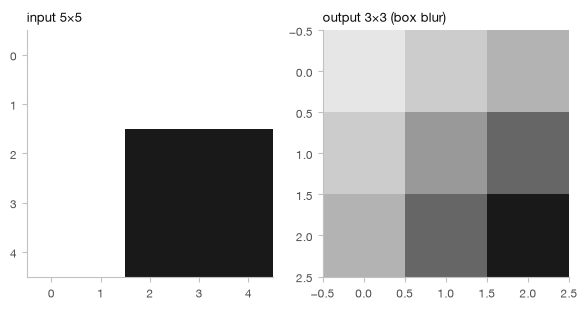

In [6]:
# SLIDING THE KERNEL
# 5x5 input image
# 3x3 kernel
n_out = image.shape[0] - kernel.shape[0] + 1     # 5 - 3 + 1 = 3
output = np.zeros((n_out, n_out))
for row in range(n_out):                          # top to bottom
    for col in range(n_out):                      # left to right
        patch, products, total = conv_step(image, kernel, row, col)
        output[row, col] = total
print(output)
assert np.allclose(output, [[90, 80, 70], [80, 60, 40], [70, 40, 10]])   # slide 15

# input and output side by side, on the same grey scale (0 = black, 100 = white)
fig, axs = plt.subplots(1, 2, figsize=(7, 3.2))
axs[0].imshow(image, cmap="gray", vmin=0, vmax=100)
axs[0].set_title("input 5×5")
axs[1].imshow(output, cmap="gray", vmin=0, vmax=100)
axs[1].set_title("output 3×3 (box blur)")
for ax in axs:
    ax.grid(False)
plt.show()

**Observation.** Sliding `conv_step` over the 9 positions gives the full box-blur output of slide 15. The sharp
jump 100 → 10 has become a ramp 90 → 60 → 10. The output is 3×3, not 5×5, because without padding the window
cannot be centred on the border pixels (§2).

## 2. Output size, padding and stride (slides 16–18 and 44)

For one dimension (height or width), with input size $n$, kernel size $k$, padding $p$ and stride $s$:

$$n_{out} = \left\lfloor \frac{n + 2p - k}{s} \right\rfloor + 1$$

Python's `//` is exactly this floor division.

In [7]:
def output_size(n, k, padding=0, stride=1):
    # Slide 16: floor((n + 2*padding - k) / stride) + 1, for one dimension.
    return (n + 2*padding - k) // stride + 1


# input 5x5; k 3x3, padding 0, stride 2
print(output_size(5, 3, 0, 2))

2


The same formula for every padding/stride example in the slides:

In [8]:
checks = [   # (n, k, padding, stride, expected, where it comes from)
    (5, 3, 0, 1, 3, "slide 15: no padding ('valid'), stride 1"),
    (5, 3, 1, 1, 5, "slide 17: padding 1 keeps the 5×5 size ('same')"),
    (5, 3, 0, 2, 2, "slide 18: stride 2"),
    (32, 5, 2, 1, 32, "slide 44: the question before the break"),
]
for n, k, p, s, expected, where in checks:
    got = output_size(n, k, p, s)
    assert got == expected
    print(f"n={n:>2}, k={k}, p={p}, s={s}  ->  {got}×{got}   {where}")

n= 5, k=3, p=0, s=1  ->  3×3   slide 15: no padding ('valid'), stride 1
n= 5, k=3, p=1, s=1  ->  5×5   slide 17: padding 1 keeps the 5×5 size ('same')
n= 5, k=3, p=0, s=2  ->  2×2   slide 18: stride 2
n=32, k=5, p=2, s=1  ->  32×32   slide 44: the question before the break


**Answer to slide 44** (32×32 input, 5×5 kernel, padding 2, stride 1): $(32 + 2·2 - 5)/1 + 1 = 32$, so the output
is **32×32**. Padding $p = (k-1)/2 = 2$ is exactly the "same" padding for a 5×5 kernel: the kernel can be centred
on every input pixel, so the size does not change.

**Padding.** The slides compare two ways to invent the missing border pixels (slide 17):
- **zero**: add black pixels (value 0). Cheap, but it creates a fake dark frame, i.e. fake edges at the border.
- **mirror**: repeat the border pixels outward (`a b c | c b a`), so the border continues smoothly and no fake edge appears.

In code both are `np.pad(image, p, mode=...)`: zeros are `mode="constant"`, mirror is `mode="symmetric"`.
Careful with the names: SciPy calls the same mirror `"reflect"`, while NumPy's `"reflect"` and SciPy's `"mirror"`
are a different mode that does **not** repeat the edge pixel (`a b c | b a`).

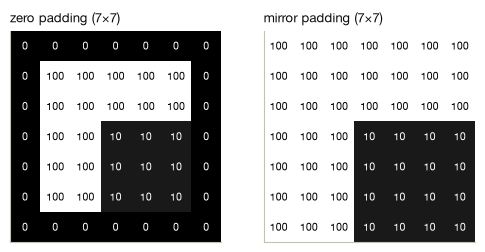

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3))
draw_values(axs[0], np.pad(image, 1, mode="constant"), "zero padding (7×7)")
draw_values(axs[1], np.pad(image, 1, mode="symmetric"), "mirror padding (7×7)")
plt.show()

## 3. `conv2d` from scratch (slide 9)

The slide formula for one output pixel is $\sum_i \sum_j I(x+i,\,y+j)\,K(i,j)$, which is exactly `conv_step`.
`conv2d` (the class exercise: the `#TODO` in `conv2d(image, kernel, padding, stride, pad_mode="constant")`; defaults `padding=0, stride=1` added for the final timing cell) is the
sliding loop of §1.1 made general:

1. pad the image with `np.pad` (`pad_mode="constant"` = zeros, `"symmetric"` = mirror; `padding=0` adds nothing);
2. compute the output size with the formula from §2;
3. for every output pixel `(row, col)`, call `conv_step` on the window whose top-left corner is
   `(row·stride, col·stride)` in the padded image.

Like PyTorch and the slides, the kernel is **not flipped**, so strictly speaking this is cross-correlation (§6).

In [10]:
def conv2d(image, kernel, padding=0, stride=1, pad_mode="constant"):
    k = kernel.shape[0]
    padded = np.pad(image, padding, mode=pad_mode)
    out_h = output_size(image.shape[0], k, padding, stride)
    out_w = output_size(image.shape[1], k, padding, stride)
    out = np.zeros((out_h, out_w))
    for row in range(out_h):
        for col in range(out_w):
            patch, products, total = conv_step(padded, kernel, row*stride, col*stride)
            out[row, col] = total
    return out


assert np.allclose(conv2d(image, kernel, 0, 1), output)   # same as the sliding loop of §1.1

### 3.1 Check against all eight hand-worked outputs (slide 34)

Every number below was computed by hand on the slides. The `assert` stops the notebook if `conv2d` disagrees
with any of them by more than the slides' rounding (0.05).

identity  output (3, 3) matches slide 34
box_blur  output (3, 3) matches slide 34
gaussian  output (3, 3) matches slide 34
sharpen   output (3, 3) matches slide 34
outline   output (3, 3) matches slide 34
emboss    output (3, 3) matches slide 34
sobel_x   output (3, 3) matches slide 34
sobel_y   output (3, 3) matches slide 34


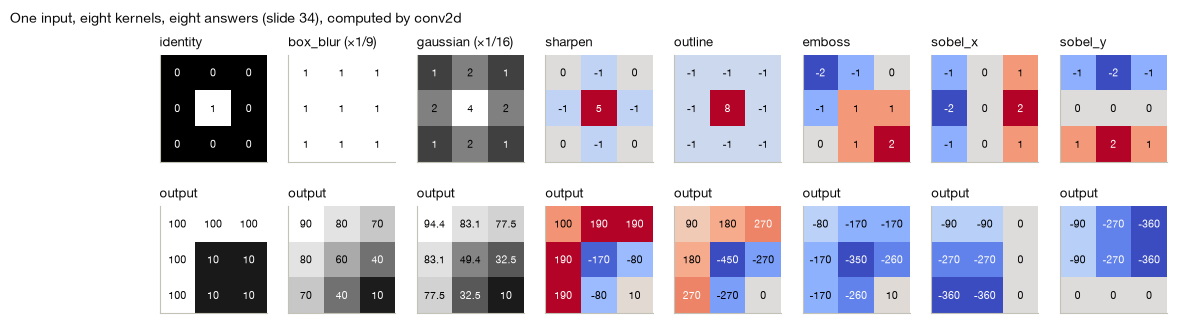

In [11]:
SLIDE_34 = {   # 3×3 outputs worked by hand on the slides (no padding, stride 1)
    "identity": [[100, 100, 100], [100, 10, 10], [100, 10, 10]],
    "box_blur": [[90, 80, 70], [80, 60, 40], [70, 40, 10]],
    "gaussian": [[94.4, 83.1, 77.5], [83.1, 49.4, 32.5], [77.5, 32.5, 10]],
    "sharpen":  [[100, 190, 190], [190, -170, -80], [190, -80, 10]],
    "outline":  [[90, 180, 270], [180, -450, -270], [270, -270, 0]],
    "emboss":   [[-80, -170, -170], [-170, -350, -260], [-170, -260, 10]],
    "sobel_x":  [[-90, -90, 0], [-270, -270, 0], [-360, -360, 0]],
    "sobel_y":  [[-90, -270, -360], [-90, -270, -360], [0, 0, 0]],
}

outputs = {name: conv2d(image, kernel, 0, 1) for name, kernel in KERNELS.items()}
for name, expected in SLIDE_34.items():
    assert np.allclose(outputs[name], expected, atol=0.05), name
    print(f"{name:9s} output {outputs[name].shape} matches slide 34")

fig, axs = plt.subplots(2, 8, figsize=(13, 3.6))
for k, (name, kernel) in enumerate(KERNELS.items()):
    draw_values(axs[0, k], kernel * (9 if name == "box_blur" else 16 if name == "gaussian" else 1),
                name + (" (×1/9)" if name == "box_blur" else " (×1/16)" if name == "gaussian" else ""))
    draw_values(axs[1, k], outputs[name], "output")
fig.suptitle("One input, eight kernels, eight answers (slide 34), computed by conv2d", x=0.01, ha="left")
show_and_save(fig, "toy_eight_kernels.png")

### 3.2 Padding, stride and edge strength (slides 17, 18 and 31)

zero padding, mirror padding, stride 2 and the Sobel magnitude all match slides 17, 18 and 31


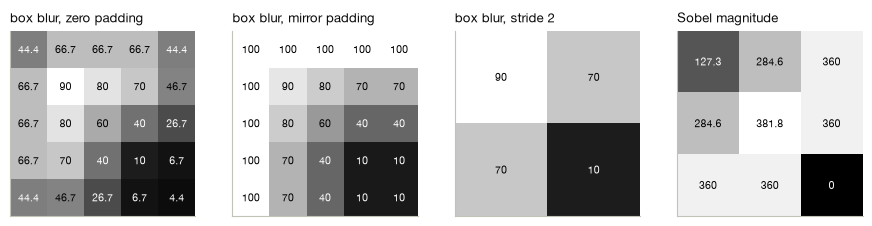

In [12]:
zero_pad = conv2d(image, KERNELS["box_blur"], 1, 1)
mirror_pad = conv2d(image, KERNELS["box_blur"], 1, 1, "symmetric")
stride_2 = conv2d(image, KERNELS["box_blur"], 0, 2)
magnitude = np.sqrt(outputs["sobel_x"] ** 2 + outputs["sobel_y"] ** 2)     # slide 31: sqrt(Gx² + Gy²)

assert np.allclose(zero_pad, [[44.4, 66.7, 66.7, 66.7, 44.4], [66.7, 90, 80, 70, 46.7], [66.7, 80, 60, 40, 26.7],
                              [66.7, 70, 40, 10, 6.7], [44.4, 46.7, 26.7, 6.7, 4.4]], atol=0.05)
assert np.allclose(mirror_pad, [[100, 100, 100, 100, 100], [100, 90, 80, 70, 70], [100, 80, 60, 40, 40],
                                [100, 70, 40, 10, 10], [100, 70, 40, 10, 10]], atol=0.05)
assert np.allclose(stride_2, [[90, 70], [70, 10]])
assert np.allclose(magnitude, [[127.3, 284.6, 360], [284.6, 381.8, 360], [360, 360, 0]], atol=0.05)
print("zero padding, mirror padding, stride 2 and the Sobel magnitude all match slides 17, 18 and 31")

fig, axs = plt.subplots(1, 4, figsize=(11, 3))
draw_values(axs[0], zero_pad, "box blur, zero padding")
draw_values(axs[1], mirror_pad, "box blur, mirror padding")
draw_values(axs[2], stride_2, "box blur, stride 2")
draw_values(axs[3], magnitude, "Sobel magnitude")
show_and_save(fig, "toy_padding_stride_magnitude.png")

**Observation.** All match the slides. Zero padding gives the output a dark frame (44.4 in the corners instead of
100): the invented black pixels look like an edge that is not in the image. Mirror padding keeps the corners at 100.
Stride 2 keeps every second window, i.e. the four corners of the stride-1 output (90, 70, 70, 10), which halves the
resolution in each direction. The Sobel magnitude lights up the whole L-shaped border (381.8 at the lesion's
corner) and is 0 inside the lesion and on flat skin.

### 3.3 "Your turn" (slide 33): four kernels on the window at (1, 2)

In [13]:
for name in ["box_blur", "sharpen", "sobel_x", "sobel_y"]:
    patch, products, total = conv_step(image, KERNELS[name], 1, 2)
    assert np.isclose(total, outputs[name][1, 2])             # same number as cell (1, 2) of conv2d's output
    print(f"{name:9s} = {fmt(total)}")
print("\nwindow at (1, 2):\n", patch)

box_blur  = 40
sharpen   = -80
sobel_x   = 0
sobel_y   = -360

window at (1, 2):
 [[100. 100. 100.]
 [ 10.  10.  10.]
 [ 10.  10.  10.]]


**Answer to slide 33.** Box blur **40** ((3·100 + 6·10) / 9), sharpen **−80** (5·10 − 100 − 10 − 10 − 10),
Sobel Gx **0**, Sobel Gy **−360**. Gx is the one that is exactly 0, and this can be seen before computing anything:
every row of the window is constant (100 100 100 / 10 10 10 / 10 10 10), so nothing changes from left to right,
and Gx only measures left-right change. Gy sees a bright row above two dark rows: a strong horizontal edge.

## 4. A real MILK10k lesion (slides 20–32)

Image **ISIC_0073863**, the lesion given in class: a dermoscopic image of a Reed nevus (benign, patient aged 5), a
dark, roughly round lesion in the centre with a darker, textured inside and no hairs. As on the slides, the filters run on the
**grayscale** image at full size (600×450), with values 0–255. Grayscale uses the project's
`preprocess_image(color_mode="gray")` from Session 2 (luma weights 0.299 R + 0.587 G + 0.114 B).

lesion_id       IL_2547802
image_type     dermoscopic
diagnosis_1         Benign
diagnosis_3          Nevus

shape (450, 600), values 6.9 to 201.1 (float, 0-255 scale)


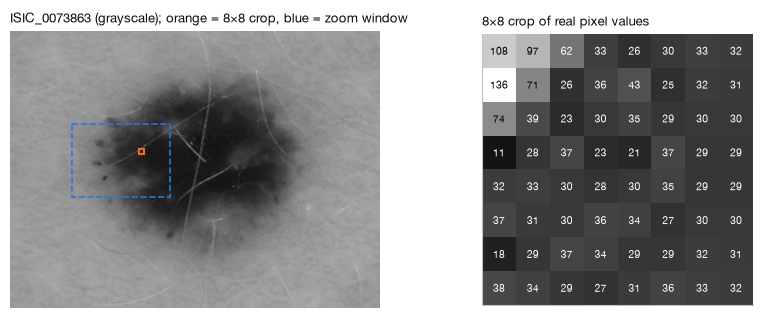

In [14]:
IMAGE_ID = "ISIC_0073863"                # the lesion id given in class
meta = load_metadata()
print(meta.set_index("isic_id").loc[IMAGE_ID, ["lesion_id", "image_type", "diagnosis_1", "diagnosis_3"]].to_string())

gray, info = preprocess_image(image_path(IMAGE_ID), size=None, color_mode="gray", normalize="none")
gray = gray[..., 0].astype(np.float64)  # (450, 600, 1) float32 -> (450, 600) float64, NumPy's default precision
print(f"\nshape {gray.shape}, values {gray.min():.1f} to {gray.max():.1f} (float, 0-255 scale)")

# An 8×8 crop of real pixel values, like slide 8: a bright spot inside the dark lesion
CROP = (192, 210)                       # top-left corner (row, column)
crop = gray[CROP[0]:CROP[0] + 8, CROP[1]:CROP[1] + 8]
ZOOM = (slice(150, 270), slice(100, 260))   # the lesion's left border and its inside, used to zoom in below

fig, axs = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
axs[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axs[0].add_patch(plt.Rectangle((CROP[1] - 0.5, CROP[0] - 0.5), 8, 8, fill=False, ec="#eb6834", lw=1.5))
axs[0].add_patch(plt.Rectangle((ZOOM[1].start, ZOOM[0].start), 160, 120, fill=False, ec="#2a78d6", lw=1.2, ls="--"))
axs[0].set_title(f"{IMAGE_ID} (grayscale); orange = 8×8 crop, blue = zoom window")
axs[0].axis("off")
draw_values(axs[1], crop.round(), "8×8 crop of real pixel values")
show_and_save(fig, "lesion_and_crop.png")

**Observation.** As on slide 8, to the computer the image is just numbers. This crop sits inside the lesion: most
values are 21–43 (dark lesion), with a bright spot in the top-left corner (108–136) and one very dark pixel (11).
Such small bright and dark structures inside the lesion are what the filters below react to most.

### 4.1 The kernels for the real image

The 3×3 kernels from §0, plus the two blurs used on slide 20: a **5×5 box** and a **Gaussian with σ = 2.2**.
The Gaussian kernel is built from its formula $G(x, y) \propto e^{-(x^2+y^2)/(2\sigma^2)}$, cut at a radius of 3σ
(99.7% of the bell) and normalised so the weights sum to 1. The 3×3 `[1 2 1]` kernel of the slides is the same
formula with a tiny σ: when $e^{-1/(2\sigma^2)} = 1/2$, i.e. $\sigma = 1/\sqrt{2\ln 2} \approx 0.85$, the weights
are exactly 1/16 · [[1, 2, 1], [2, 4, 2], [1, 2, 1]] (checked below).

In [15]:
def gaussian_kernel(sigma, radius=None):
    # Square Gaussian kernel exp(-(x² + y²) / (2σ²)), normalised so its weights sum to 1.
    radius = int(np.ceil(3 * sigma)) if radius is None else radius
    x = np.arange(-radius, radius + 1)
    g = np.exp(-x ** 2 / (2 * sigma ** 2))      # 1-D bell curve
    kernel = np.outer(g, g)                      # 2-D: g(x)·g(y) = exp(-(x² + y²) / (2σ²))
    return kernel / kernel.sum()


assert np.allclose(gaussian_kernel(1 / np.sqrt(2 * np.log(2)), radius=1), KERNELS["gaussian"])
print("the slide's 3×3 Gaussian = gaussian_kernel(sigma=0.85, radius=1)")

REAL_KERNELS = {
    "box blur 5×5": np.ones((5, 5)) / 25,
    "Gaussian σ=2.2": gaussian_kernel(2.2),
    "sharpen": KERNELS["sharpen"],
    "emboss": KERNELS["emboss"],
    "outline": KERNELS["outline"],
    "Sobel Gx": KERNELS["sobel_x"],
    "Sobel Gy": KERNELS["sobel_y"],
}
for name, kernel in REAL_KERNELS.items():
    print(f"{name:15s} {kernel.shape[0]}×{kernel.shape[1]}, weights sum to {kernel.sum():.3g}")

the slide's 3×3 Gaussian = gaussian_kernel(sigma=0.85, radius=1)
box blur 5×5    5×5, weights sum to 1
Gaussian σ=2.2  15×15, weights sum to 1
sharpen         3×3, weights sum to 1
emboss          3×3, weights sum to 1
outline         3×3, weights sum to 0
Sobel Gx        3×3, weights sum to 0
Sobel Gy        3×3, weights sum to 0


### 4.2 My `conv2d` vs. `fast_conv2d` (SciPy)

`fast_conv2d` is the helper given in class: the same operation done by `scipy.ndimage.correlate` in optimized C.
SciPy's `mode="reflect"` is the mirror padding (NumPy's `"symmetric"`), and SciPy always keeps the output the same
size as the input, i.e. padding = kernel radius (1 for a 3×3 kernel, 7 for the 15×15 Gaussian). Each kernel is
applied twice to the full image, once with my loop-based `conv2d` and once with `fast_conv2d`. The two must agree to
floating-point precision.

In [16]:
def fast_conv2d(image, kernel):
    """Same as conv2d(..., padding=1, pad_mode="symmetric") but in optimized C."""
    return ndimage.correlate(image, kernel, mode="reflect")

In [17]:
mine, scipy_out, rows = {}, {}, []
for name, kernel in REAL_KERNELS.items():
    start = time.perf_counter()
    mine[name] = conv2d(gray, kernel, kernel.shape[0] // 2, 1, "symmetric")
    t_mine = time.perf_counter() - start
    start = time.perf_counter()
    scipy_out[name] = fast_conv2d(gray, kernel)
    t_scipy = time.perf_counter() - start
    rows.append({"kernel": name, "output shape": mine[name].shape,
                 "max |conv2d - fast_conv2d|": np.abs(mine[name] - scipy_out[name]).max(),
                 "my conv2d (s)": round(t_mine, 2), "fast_conv2d (s)": round(t_scipy, 4)})
    assert mine[name].shape == gray.shape and np.allclose(mine[name], scipy_out[name])

pd.DataFrame(rows).set_index("kernel")

,output shape,max |conv2d - fast_conv2d|,my conv2d (s),fast_conv2d (s)
kernel,,,,
box blur 5×5,"(450, 600)",1.421085e-13,0.35,0.0038
Gaussian σ=2.2,"(450, 600)",3.694822e-13,0.38,0.0527
sharpen,"(450, 600)",0.000000e+00,0.34,0.0012
emboss,"(450, 600)",0.000000e+00,0.34,0.0013
outline,"(450, 600)",0.000000e+00,0.34,0.0014
Sobel Gx,"(450, 600)",0.000000e+00,0.33,0.0011
Sobel Gy,"(450, 600)",0.000000e+00,0.33,0.0012


**Observation.** For all seven kernels my `conv2d` and `fast_conv2d` (`scipy.ndimage.correlate`) agree to at most 4·10⁻¹³, i.e.
floating-point rounding, so the from-scratch implementation (padding included) is correct on a real image too.
The time columns already show the cost of Python loops: about a third of a second per kernel for my `conv2d`
against about a millisecond for SciPy on the 3×3 kernels (measured properly in §5).

### 4.3 Blur: box vs. Gaussian (slides 20–22)

Top row: the whole image. Bottom row: the zoom window (the lesion's left border and its inside), where the difference between
the two blurs is visible.

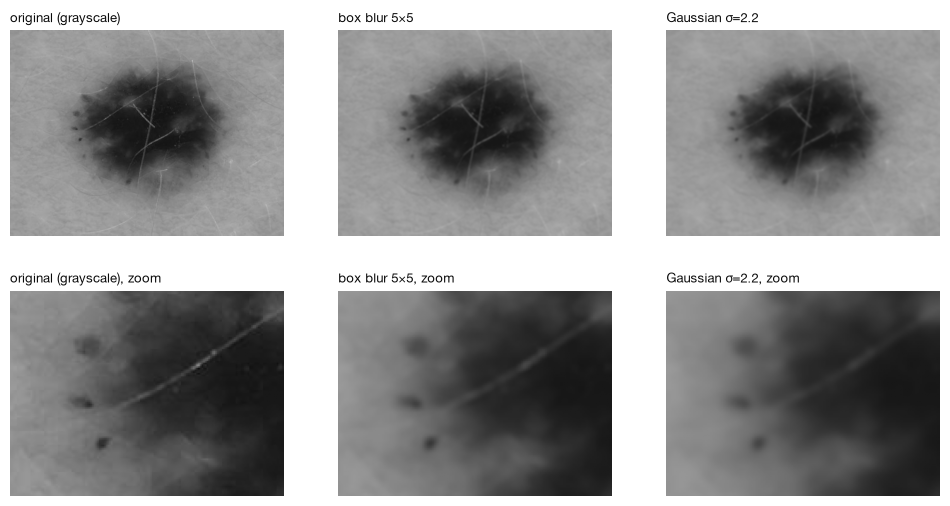

lesion mask: threshold 96, lesion = 21.2% of the image

original        mean edge strength: inside the lesion  23.6, on the skin  14.5
box blur 5×5    mean edge strength: inside the lesion  15.3, on the skin   8.2
Gaussian σ=2.2  mean edge strength: inside the lesion  13.0, on the skin   6.4


In [18]:
blur_names = ["box blur 5×5", "Gaussian σ=2.2"]
fig, axs = plt.subplots(2, 3, figsize=(12, 6.2))
for col, (title, img) in enumerate([("original (grayscale)", gray)] + [(n, mine[n]) for n in blur_names]):
    axs[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axs[1, col].imshow(img[ZOOM], cmap="gray", vmin=0, vmax=255)
    axs[0, col].set_title(title)
    axs[1, col].set_title(f"{title}, zoom")
for ax in axs.ravel():
    ax.axis("off")
show_and_save(fig, "lesion_blur.jpg")

# A rough lesion mask, made with today's tools: take the Gaussian-blurred image, keep the pixels darker than
# halfway between the lesion and the skin, then keep the largest connected piece (drops small dark specks)
smooth = mine["Gaussian σ=2.2"]
threshold = (np.percentile(smooth, 5) + np.percentile(smooth, 90)) / 2
pieces, _ = ndimage.label(smooth < threshold)                       # number each connected dark piece
lesion = pieces == np.argmax(np.bincount(pieces.ravel())[1:]) + 1   # the biggest piece
print(f"lesion mask: threshold {threshold:.0f}, lesion = {lesion.mean() * 100:.1f}% of the image\n")


def edge_strength(img):
    # Sobel magnitude; fast_conv2d is used for speed (4.2 showed it gives the same result as conv2d)
    gx = fast_conv2d(img, KERNELS["sobel_x"])
    gy = fast_conv2d(img, KERNELS["sobel_y"])
    return np.sqrt(gx ** 2 + gy ** 2)


# How much fine detail does each blur remove? Mean edge strength inside the lesion and on the skin
for title, img in [("original", gray)] + [(n, mine[n]) for n in blur_names]:
    e = edge_strength(img)
    print(f"{title:15s} mean edge strength: inside the lesion {e[lesion].mean():5.1f}, on the skin {e[~lesion].mean():5.1f}")

**Observation.** Both blurs remove fine detail. The mean edge strength inside the lesion drops from 23.6 to **15.3**
with the 5×5 box and to **13.0** with the Gaussian (−35% and −45%), and on the skin from 14.5 to 8.2 and 6.4. The
slide's two settings are not equally strong: a 5×5 box reaches only 2 pixels from the centre, while the σ = 2.2
Gaussian (cut at 3σ) reaches 7 pixels, so the Gaussian blurs more. The weighting also differs (slide 21). In the box,
every pixel inside the 5×5 counts the same and the weight drops to 0 at its edge. In the Gaussian, the weights fall
off smoothly with distance, which gives the smoother, more natural look in the zoom.

The lesion mask above is itself a use of blur. Thresholding the raw image would also pick up dark specks and noise,
whereas thresholding the blurred image gives one clean region (21.2% of the image), used again in 4.6.

**For the project.** The structures inside the lesion are diagnostic, and blur removes exactly that fine detail.
Blur is useful to clean up (e.g. for a mask), but texture features must be computed on the unblurred image.

### 4.4 Sharpen, emboss, outline (slides 23–27)

Sharpen can leave the 0–255 range (a dark pixel next to a bright one can go below 0, slide 24), so it is
**clipped** to [0, 255] for display. Outline and emboss produce extreme values, so for display the most extreme 1%
at each end is ignored and the rest is stretched from black to white (the rule in the footnote of slide 25).

sharpen output range: -133 to 339 (0.17% of pixels outside 0-255, clipped for display)


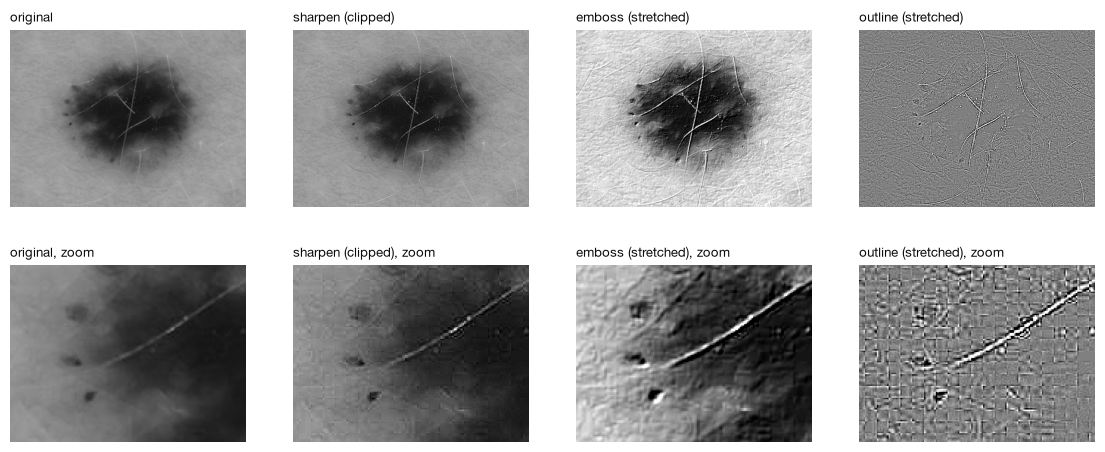

In [19]:
def stretch(img, low=1, high=99):
    # Display only: ignore the most extreme 1% at each end and stretch the rest to [0, 1].
    lo, hi = np.percentile(img, [low, high])
    return np.clip((img - lo) / (hi - lo), 0, 1)


sharp = mine["sharpen"]
print(f"sharpen output range: {sharp.min():.0f} to {sharp.max():.0f} "
      f"({np.mean((sharp < 0) | (sharp > 255)) * 100:.2f}% of pixels outside 0-255, clipped for display)")

panels = [("original", gray / 255), ("sharpen (clipped)", np.clip(sharp, 0, 255) / 255),
          ("emboss (stretched)", stretch(mine["emboss"])), ("outline (stretched)", stretch(mine["outline"]))]
fig, axs = plt.subplots(2, 4, figsize=(14, 5.6))
for col, (title, img) in enumerate(panels):
    axs[0, col].imshow(img, cmap="gray", vmin=0, vmax=1)
    axs[1, col].imshow(img[ZOOM], cmap="gray", vmin=0, vmax=1)
    axs[0, col].set_title(title)
    axs[1, col].set_title(f"{title}, zoom")
for ax in axs.ravel():
    ax.axis("off")
show_and_save(fig, "lesion_sharpen_emboss_outline.jpg")

**Observation.** Sharpen makes the structures inside the lesion and its border crisper. 0.17% of the pixels leave
the 0–255 range (−133 to 339): the overshoot is largest where a bright spot touches dark lesion, as in the 8×8 crop,
and those pixels are clipped. Emboss gives the 3-D relief look of slide 25: each edge is light on one side and dark
on the other along the ↘ diagonal. Outline (weights sum to 0) turns the flat skin into a uniform mid-grey (≈ 0) and
keeps only local changes: the inside of the lesion responds most, the border less, because it is a gradual change
over many pixels rather than a step. Outline also responds to something that is not skin at all, checked next.

### 4.5 Where does the grid in the outline zoom come from?

The zoomed outline shows a regular grid of small squares, which is not a skin structure. MILK10k images are JPEG
files, and JPEG compresses an image in separate **8×8 blocks**. If the grid comes from the blocks, the outline
response must be stronger on the pixels next to a block boundary (positions 7 and 0 when counting modulo 8).

In [20]:
abs_outline = np.abs(mine["outline"])
jpeg = pd.DataFrame({"columns": [abs_outline[:, m::8].mean() for m in range(8)],    # columns c with c % 8 == m
                     "rows": [abs_outline[m::8, :].mean() for m in range(8)]},       # rows r with r % 8 == m
                    index=pd.Index(range(8), name="position mod 8"))
print("mean |outline response| by position inside the 8×8 JPEG blocks")
jpeg.T.round(1)

mean |outline response| by position inside the 8×8 JPEG blocks


position mod 8,0,1,2,3,4,5,6,7
columns,11.3,6.8,7.3,7.3,7.3,7.2,6.7,11.3
rows,11.4,6.5,7.5,7.4,7.3,7.3,6.4,11.4


**Observation.** The outline response is about **1.6× stronger** on the pixels on either side of an 8×8 block
boundary (positions 7 and 0: about 11.3) than inside the blocks (6.4–7.5), for columns and for rows alike. Each
8×8 block is compressed separately, which leaves tiny jumps between blocks. They are invisible to the eye, but a
filter that amplifies differences between neighbours picks them up.

**For the project.** Edge and texture features (Session 5) and CNN filters can respond to compression artifacts,
not only to skin structure. This becomes a problem (a shortcut) only if the compression differs between classes,
e.g. if one device or clinic saved its images at a different JPEG quality. That is worth checking before trusting
texture features.

### 4.5 Sobel edges (slides 28–32)

Gx responds to left↔right changes (vertical edges), Gy to top↔bottom changes (horizontal edges). The magnitude
$\sqrt{G_x^2 + G_y^2}$ measures edge strength in any direction. For Gx and Gy, mid-grey = 0, dark = negative
(brighter → darker along the axis), light = positive.

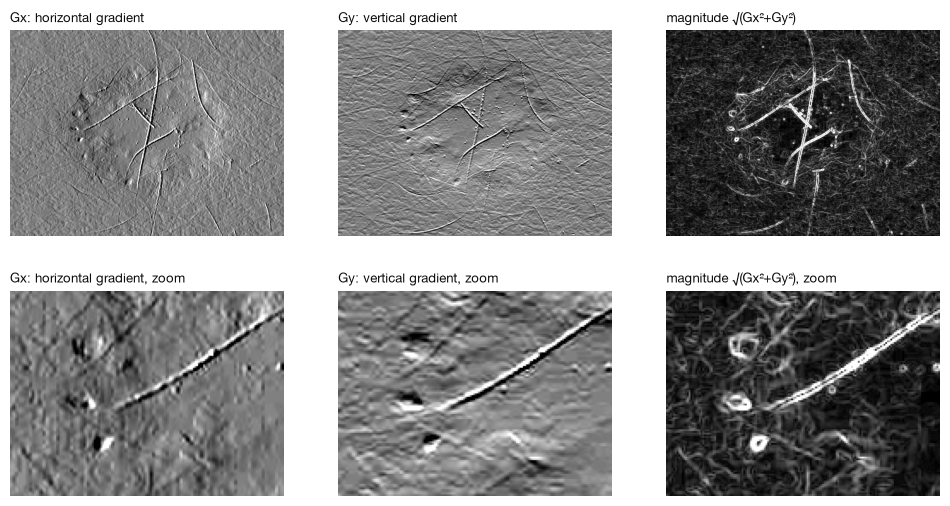

edge magnitude: median 13, 95th percentile 38, max 435
inside the lesion           19.7% of the image, mean edge  23.1,  80% of the strongest 1% edges
lesion border (8-px band)    3.1% of the image, mean edge  29.2,   9% of the strongest 1% edges
skin                        77.3% of the image, mean edge  14.2,  11% of the strongest 1% edges


In [21]:
gx, gy = mine["Sobel Gx"], mine["Sobel Gy"]
edge = np.sqrt(gx ** 2 + gy ** 2)
lim = np.percentile(np.abs(np.concatenate([gx.ravel(), gy.ravel()])), 99)   # same symmetric scale for Gx and Gy

fig, axs = plt.subplots(2, 3, figsize=(12, 6.2))
for col, (title, img, kw) in enumerate([("Gx: horizontal gradient", gx, dict(vmin=-lim, vmax=lim)),
                                        ("Gy: vertical gradient", gy, dict(vmin=-lim, vmax=lim)),
                                        ("magnitude √(Gx²+Gy²)", edge, dict(vmin=0, vmax=np.percentile(edge, 99)))]):
    axs[0, col].imshow(img, cmap="gray", **kw)
    axs[1, col].imshow(img[ZOOM], cmap="gray", **kw)
    axs[0, col].set_title(title)
    axs[1, col].set_title(f"{title}, zoom")
for ax in axs.ravel():
    ax.axis("off")
show_and_save(fig, "lesion_sobel.jpg")

print(f"edge magnitude: median {np.median(edge):.0f}, 95th percentile {np.percentile(edge, 95):.0f}, "
      f"max {edge.max():.0f}")

# Where are the edges? Split the image with the lesion mask of 4.3
border = ndimage.binary_dilation(lesion, iterations=4) & ~ndimage.binary_erosion(lesion, iterations=4)  # 8-px band on the outline
inside, skin = lesion & ~border, ~lesion & ~border
top = edge > np.percentile(edge, 99)          # the 1% strongest edge pixels
for name, region in [("inside the lesion", inside), ("lesion border (8-px band)", border), ("skin", skin)]:
    print(f"{name:26s} {region.mean() * 100:5.1f}% of the image, mean edge {edge[region].mean():5.1f}, "
          f"{(top & region).sum() / top.sum() * 100:3.0f}% of the strongest 1% edges")

**Observation.** Gx shows the left and right sides of the lesion with opposite signs (bright skin → dark lesion on
the left gives negative values, dark → bright on the right gives positive values), and Gy does the same for the top
and bottom. The magnitude combines both into an edge map like slide 32.

The lesion mask shows where the edges are. The inside of the lesion is 19.7% of the image but holds **80%** of the
strongest 1% edge pixels: its fine structures (dots, bright spots) give many sharp local changes. The border band has
the highest *average* edge strength (29.2) but only 9% of the strongest edges, because the border is a gradual
change spread over several pixels. The skin is mostly weak texture (14.2).

**For the project.** Edge statistics computed separately for the inside and the border of the lesion measure two
different things: internal texture vs. border sharpness (the "B" of the ABCD rule dermatologists use). This lesion
has no hairs, but many MILK10k images do. On ISIC_4566874, for example, a hair gave a stronger edge (182) than the
lesion border (151). Hairs therefore need to be removed or masked before edge features are computed.

## 5. Speed: naive loops vs. vectorized NumPy vs. SciPy (slide 48)

`conv2d` runs a Python loop over every **output pixel** (270,000 of them for a 600×450 image). The vectorized
version swaps the loops: it loops over the **kernel cells** instead (9 for a 3×3 kernel). For each weight
$K[i, j]$ it takes, in one slice, the pixel that sits under that weight for *every* window at once, and adds
`weight × that whole shifted image` to the output. Same arithmetic, same result, but the inner work is done by
NumPy in C on whole arrays.

In [22]:
def conv2d_vectorized(image, kernel, padding, stride, pad_mode="constant"):
    # Same result as conv2d, but the loop runs over the kernel cells, not the output pixels.
    kh, kw = kernel.shape
    padded = np.pad(image, padding, mode=pad_mode)
    out_h = output_size(image.shape[0], kh, padding, stride)
    out_w = output_size(image.shape[1], kw, padding, stride)
    out = np.zeros((out_h, out_w))
    for i in range(kh):
        for j in range(kw):
            # pixel under weight (i, j) in every window: rows i, i+stride, ...; columns j, j+stride, ...
            shifted = padded[i:i + stride * out_h:stride, j:j + stride * out_w:stride]
            out += kernel[i, j] * shifted
    return out


# Same results as conv2d: every toy case (all kernels, both paddings, strides 1 and 2) and the real image
for kernel in KERNELS.values():
    for padding, pad_mode, stride in [(0, "constant", 1), (1, "constant", 1), (1, "symmetric", 1), (0, "constant", 2), (1, "symmetric", 2)]:
        assert np.allclose(conv2d_vectorized(image, kernel, padding, stride, pad_mode),
                           conv2d(image, kernel, padding, stride, pad_mode))
for name, kernel in REAL_KERNELS.items():
    assert np.allclose(conv2d_vectorized(gray, kernel, kernel.shape[0] // 2, 1, "symmetric"), mine[name])
print("conv2d_vectorized == conv2d on every toy case and on the real image")

conv2d_vectorized == conv2d on every toy case and on the real image


In [23]:
def best_time(fn, repeats):
    # Fastest of a few runs, in seconds (the minimum is least disturbed by other programs).
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        times.append(time.perf_counter() - start)
    return min(times)


rows = []
for name in ["Sobel Gx", "Gaussian σ=2.2"]:
    kernel = REAL_KERNELS[name]
    p = kernel.shape[0] // 2
    t_naive = best_time(lambda: conv2d(gray, kernel, p, 1, "symmetric"), repeats=1)
    t_vec = best_time(lambda: conv2d_vectorized(gray, kernel, p, 1, "symmetric"), repeats=5)
    t_scipy = best_time(lambda: fast_conv2d(gray, kernel), repeats=5)
    for method, t in [("naive loops (conv2d)", t_naive), ("vectorized NumPy", t_vec), ("fast_conv2d (SciPy, C)", t_scipy)]:
        rows.append({"kernel": f"{name} ({kernel.shape[0]}×{kernel.shape[1]})", "method": method,
                     "time (ms)": round(t * 1000, 1), "speed-up vs naive": f"{t_naive / t:,.0f}×"})
speed = pd.DataFrame(rows).set_index(["kernel", "method"])
speed

time (ms) speed-up vs naive
kernel                 method                                             
Sobel Gx (3×3)         naive loops (conv2d)        344.2                1×
                       vectorized NumPy              1.6              217×
                       fast_conv2d (SciPy, C)        1.1              300×
Gaussian σ=2.2 (15×15) naive loops (conv2d)        380.7                1×
                       vectorized NumPy             35.4               11×
                       fast_conv2d (SciPy, C)       51.9                7×

**Observation.** Same result, very different cost. For the 3×3 Sobel kernel the vectorized NumPy version and SciPy
are much faster than the pixel loop: about **200×** for the vectorized version and **300×** for `fast_conv2d`, so a
third of a second becomes one to two milliseconds (the exact factors vary a little from run to run). The naive time
barely depends on the kernel size, because it is dominated by Python's overhead for the 270,000 loop steps
(one `conv_step` call each). The vectorized time grows with the number of kernel cells: 9 → 225 cells (25× more)
makes it more than ten times slower, so the gain for the 15×15 Gaussian is only about 10×. At that size my NumPy version is
even a bit faster than `ndimage.correlate`, since both do the same 225 multiply-adds per pixel.

In practice a large Gaussian is not computed this way. It is **separable** (`gaussian_kernel` builds it as
`np.outer(g, g)`), so it can be applied as two 1-D passes of 15 weights instead of one pass of 225, which is what
`scipy.ndimage.gaussian_filter` does (Session 4 homework).

## 6. Convolution vs. correlation (slide 36)

True mathematical convolution flips the kernel by 180° before sliding it. What we computed (and what PyTorch's
`nn.Conv2d` computes) is cross-correlation: no flip. SciPy has both: `ndimage.correlate` and `ndimage.convolve`.

In [24]:
corr, conv = {}, {}
for name, kernel in KERNELS.items():
    corr[name] = ndimage.correlate(image, kernel, mode="reflect")
    conv[name] = ndimage.convolve(image, kernel, mode="reflect")
    # convolution = correlation with the kernel rotated by 180° (flip rows and columns)
    assert np.allclose(conv[name], ndimage.correlate(image, np.flip(kernel), mode="reflect"))
    same = np.allclose(conv[name], corr[name])
    symmetric = np.array_equal(kernel, np.flip(kernel))
    print(f"{name:9s} kernel unchanged by a 180° flip: {str(symmetric):5s} -> convolve == correlate: {same}")

assert np.allclose(conv["sobel_x"], -corr["sobel_x"])     # for Sobel the flip only changes the sign

identity  kernel unchanged by a 180° flip: True  -> convolve == correlate: True
box_blur  kernel unchanged by a 180° flip: True  -> convolve == correlate: True
gaussian  kernel unchanged by a 180° flip: True  -> convolve == correlate: True
sharpen   kernel unchanged by a 180° flip: True  -> convolve == correlate: True
outline   kernel unchanged by a 180° flip: True  -> convolve == correlate: True
emboss    kernel unchanged by a 180° flip: False -> convolve == correlate: False
sobel_x   kernel unchanged by a 180° flip: False -> convolve == correlate: False
sobel_y   kernel unchanged by a 180° flip: False -> convolve == correlate: False


**Observation.** For the five kernels that look the same after a 180° rotation (identity, both blurs, sharpen,
outline), convolution and correlation give identical results, so the naming never matters for them. For emboss
and Sobel they differ, and for Sobel the flip only changes the sign (flipped Gx = −Gx): the edge is found in the
same place with the opposite sign. A CNN learns its kernels, so it would simply learn the flipped version, which is
why deep-learning frameworks skip the flip (slide 36).

## 7. From one hand-made kernel to a CNN layer (slides 35 and 37)

A convolutional layer is **many kernels applied in parallel**; each produces one feature map. Below, a PyTorch
`nn.Conv2d` layer with 8 output channels gets our 8 hand-made kernels as its weights. It must then produce exactly
the 8 outputs of §3. In a real CNN the only difference is where the weights come from: they start random and are
**learned** by training instead of chosen by hand.

In [25]:
torch.manual_seed(config.SEED)                           # the same "random" start every run
layer = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=0, bias=False)
print("weight shape (out_channels, in_channels, kH, kW):", tuple(layer.weight.shape))
with np.printoptions(precision=2):
    print("a freshly created layer starts with random weights, e.g. kernel 0:\n", layer.weight[0, 0].detach().numpy())

bank = np.stack(list(KERNELS.values()))                  # (8, 3, 3): our 8 kernels
with torch.no_grad():
    layer.weight.copy_(torch.tensor(bank, dtype=torch.float32)[:, None])   # -> (8, 1, 3, 3)
    maps = layer(torch.tensor(image, dtype=torch.float32)[None, None])      # input (batch 1, channel 1, 5, 5)
print("\nfeature maps shape (batch, channels, H, W):", tuple(maps.shape))
for k, name in enumerate(KERNELS):
    assert np.allclose(maps[0, k].numpy(), outputs[name], atol=1e-3)
print("nn.Conv2d with our 8 kernels == our conv2d, for all 8 kernels (so PyTorch does not flip the kernel)")

# The output-size formula of §2 is the one PyTorch uses: stride 2 + padding 1 halves a 600×450 image
real = torch.tensor(gray, dtype=torch.float32)[None, None]          # (1, 1, 450, 600)
with torch.no_grad():
    down = nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1)(real)
print(f"\nstride 2, padding 1 on the lesion: {tuple(real.shape)} -> {tuple(down.shape)}; "
      f"formula: {output_size(450, 3, 1, 2)}×{output_size(600, 3, 1, 2)}")
assert down.shape[2:] == (output_size(450, 3, 1, 2), output_size(600, 3, 1, 2))

# And on the real image with zero padding, PyTorch's Sobel Gx equals my conv2d's
with torch.no_grad():
    sobel_layer = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
    sobel_layer.weight.copy_(torch.tensor(KERNELS["sobel_x"], dtype=torch.float32)[None, None])
    torch_gx = sobel_layer(real)[0, 0].numpy()
diff = np.abs(torch_gx - conv2d(gray, KERNELS["sobel_x"], 1, 1)).max()
print(f"Sobel Gx on the lesion: max |PyTorch - my conv2d| = {diff:.1e}")

weight shape (out_channels, in_channels, kH, kW): (8, 1, 3, 3)
a freshly created layer starts with random weights, e.g. kernel 0:
 [[ 0.25  0.28 -0.08]
 [ 0.31 -0.07  0.07]
 [-0.16  0.2   0.29]]

feature maps shape (batch, channels, H, W): (1, 8, 3, 3)
nn.Conv2d with our 8 kernels == our conv2d, for all 8 kernels (so PyTorch does not flip the kernel)

stride 2, padding 1 on the lesion: (1, 1, 450, 600) -> (1, 8, 225, 300); formula: 225×300


Sobel Gx on the lesion: max |PyTorch - my conv2d| = 6.1e-05


**Observation.** `nn.Conv2d` performs the same operation as my `conv2d`:
- with our 8 kernels as its weights, one layer returns exactly the 8 outputs of §3 (8 kernels in parallel →
  8 feature maps, shape (1, 8, 3, 3));
- on the real lesion its Sobel Gx matches mine to 6·10⁻⁵ (float32 rounding on values of up to a few hundred);
- it does not flip the kernel, otherwise its Sobel maps would have the opposite sign;
- its output size follows the formula of §2 (stride 2 + padding 1: 450×600 → 225×300).

The only thing a CNN changes is where the weights come from. A new layer starts with random numbers like the ones
printed above, and training adjusts them, so the network learns its own feature detectors instead of the ones we
design by hand (slides 35 and 37, Session 7).

## 8. Loops vs. SciPy on the lesion (class code)

The final check done in class: the box blur on the full lesion image, with my loop-based `conv2d` and with
`fast_conv2d`, timed with `time.perf_counter()`.

In [26]:
image = gray   # the lesion ISIC_0073863 (until now, image was the 5×5 toy image)

t0 = time.perf_counter()
slow = conv2d(image, KERNELS["box_blur"], padding=1, pad_mode="symmetric")
t_slow = time.perf_counter() - t0

t0 = time.perf_counter()
fast = fast_conv2d(image, KERNELS["box_blur"])
t_fast = time.perf_counter() - t0

print(f"loops {t_slow:.3f}s | scipy {t_fast:.4f}s | {t_slow / t_fast:.0f}x faster")
print("same result:", np.allclose(slow, fast))

loops 0.336s | scipy 0.0014s | 247x faster
same result: True


## Summary

| Part | Result |
|---|---|
| `conv_step` / sliding the kernel | one window = patch → products → sum; slid over the 5×5 image it gives slide 15's output |
| `conv2d` (class exercise) | matches every hand-worked result on slides 10–34: 8 kernels, zero and mirror padding, stride 2, Sobel magnitude, slide 33 |
| vs. `fast_conv2d` (SciPy) | same output on lesion ISIC_0073863 for all 7 kernels (difference ≤ 4·10⁻¹³) |
| Speed | pixel loops ≈ 0.35 s per kernel; vectorized NumPy ≈ 2 ms (≈ 200×) and `fast_conv2d` ≈ 1 ms (≈ 300×) for 3×3, only ≈ 10× for 15×15 |
| Convolution vs. correlation | identical for kernels that are symmetric under a 180° rotation; Sobel changes sign |
| `nn.Conv2d` | same numbers as `conv2d`; a CNN layer is a bank of kernels whose weights are learned |
| On the lesion | blur removes 35–45% of the fine detail; 80% of the strongest edges are inside the lesion; outline exposes the 8×8 JPEG blocks |

**Answers to the questions in the slides:** slide 33 (§3.3), slide 44 (§2).

**What carries over to Session 5 (classical ML features):**
- compute texture and edge statistics on the unblurred image, separately for the inside and the border of the lesion;
- remove or mask hairs first;
- check that JPEG block artifacts do not differ between classes.